# 05 · Structure search

Demonstrates substructure and similarity search using the RDKit PostgreSQL cartridge (see [`ord_schema/orm/README.md`](https://github.com/open-reaction-database/ord-schema/blob/main/ord_schema/orm/README.md)). Requires the database to have been built with the RDKit cartridge -- see [`docs/local_ord_database.md`](../docs/local_ord_database.md).

In [1]:
from dotenv import load_dotenv
from rdkit import Chem
from rdkit.Chem import Draw

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()

## Substructure search

Reactions with an input compound containing a furan ring.

In [2]:
furan_smarts = "c1ccoc1"
reaction_ids = queries.substructure_search(engine, furan_smarts, limit=10)
print(f"{len(reaction_ids)} matching reactions (showing up to 10)")
reaction_ids

10 matching reactions (showing up to 10)


['ord-0007091b85f84e50b7f5026b4d3ee78e',
 'ord-0009a9fb24af41b7bfad44a408769037',
 'ord-000c488c95e14c95bbda98d1466af9b4',
 'ord-000d0aedbb4f451d80f9fd4e891b3710',
 'ord-000d5bcb1e9f4066a4afe607e97ede56',
 'ord-00164e0de63641d4887bd57196dcf2f8',
 'ord-00182cf7208c47b2ac2cec5a0488129e',
 'ord-001fb9a743934d5995ee84e394a45774',
 'ord-002e266f0e604172a6bd922df57b6c97',
 'ord-002e7193140948b5802f6435097169c6']

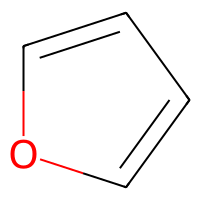

In [3]:
Draw.MolToImage(Chem.MolFromSmiles(furan_smarts), size=(200, 200))

## Similarity search

Reactions with an input compound Tanimoto-similar (Morgan fingerprint) to a query structure.

In [4]:
query_smiles = "c1ccccc1CCC(O)C"
reaction_ids = queries.similarity_search(engine, query_smiles, threshold=0.5, limit=10)
print(f"{len(reaction_ids)} matching reactions (showing up to 10)")
reaction_ids

10 matching reactions (showing up to 10)


['ord-013063a5a7d24c198cb36383884af16d',
 'ord-05e49b63873c4286a70e207fdda55ac1',
 'ord-06577567c1244d6ba8b0d223f6314eeb',
 'ord-084c3fed4d174750b117ad5ceda12071',
 'ord-08a7b8f6f9904758bb2f052f4e45040c',
 'ord-08e7029cd06f4638af02b36e0d6ed909',
 'ord-0921b3f020274752a7fd9cc4230040c8',
 'ord-114610bcc8ba4eb9b09fec460cd63226',
 'ord-12a147f5aecf48aab6c2cbe51be5bfd5',
 'ord-13a8f5e900474d069192900dbff328f1']

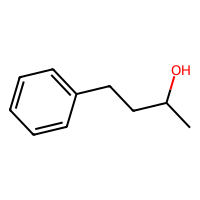

In [5]:
Draw.MolToImage(Chem.MolFromSmiles(query_smiles), size=(200, 200))